In [5]:
# Import essential libraries
import pandas as pd
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set_theme(style="whitegrid")

In [6]:
print("Data Preprocessing & Feature Engineering")
print("="*60)
print("Dataset: Customers Churn data (17 features)")
print("Goal: Transform raw data into ML-ready features")

Data Preprocessing & Feature Engineering
Dataset: Customers Churn data (17 features)
Goal: Transform raw data into ML-ready features


### Load  Dataset
Loading the TeleCo Customer Churn dataset with Cutomers Id's, Tenure, Contract Type, Avg Monthly GB usage and churned data.

In [7]:
# Folder containing CSV files
folder_path = Path(r"D:\Churn_Prediction\data\Pre_processed_data")

# Get all CSV files
csv_files = list(folder_path.glob("*.csv"))

if not csv_files:
    print("No CSV files found in the folder.")
else:
    # Load the first CSV file
    data_path = csv_files[0]

    try:
        df = pd.read_csv(data_path)
        print(f"Successfully loaded: {data_path.name}")
        print(f"\nDataset shape: {df.shape}")
        print(f"\nColumns: {df.columns}")
    except Exception as e:
        print(f"Error: {e}")

Successfully loaded: char_data_v1_20260721_161051.csv

Dataset shape: (5000, 17)

Columns: Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'monthly_charges', 'total_charges', 'internet_service', 'phone_service',
       'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes',
       'satisfaction_score', 'payment_method', 'num_additional_services',
       'last_interaction_date', 'churned'],
      dtype='object')


##  Part 1: Data Exploration

In [8]:
# Quick data overview
print(f"Total Customers: {len(df)}")
print(f"Features: {df.shape[1]}")
print("\nFirst 3 records:")
df.head(3)

Total Customers: 5000
Features: 17

First 3 records:


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-000001,49.450712,Female,11.013923,One year,65.89,896.60,Fiber optic,Yes,5.60,3.0,446.3,6.5,Bank transfer,4,2024-06-30,1
1,TC-000002,39.926035,Female,6.079738,One year,63.70,207.91,DSL,No,15.08,0.0,297.7,6.2,Credit card,3,2024-06-04,1
2,TC-000003,51.715328,Female,40.524233,Month-to-month,57.23,2533.53,Fiber optic,Yes,2.49,2.0,113.6,3.7,Electronic check,1,2024-06-23,1


#### Comprehensive Dataset Overview

Our customer churn dataset contains multiple categories of features that provide a comprehensive view of each customer's profile, service usage, billing behavior, and overall satisfaction.

**Column Categories:**

- **Customer Identity:** customer_id
- **Demographics:** age, gender
- **Account Information:** tenure_months, contract_type
- **Billing & Payments:** monthly_charges, total_charges, payment_method
- **Services Subscribed:** internet_service, phone_service, num_additional_services
- **Usage Metrics:** avg_monthly_gb_used, avg_monthly_minutes
- **Customer Support & Engagement:** num_support_tickets, last_interaction_date
- **Customer Satisfaction:** satisfaction_score
- **Target Variable:** churned

#### Data Quality Assessment

In [9]:
# Check data types and missing values
print("\nDATA QUALITY CHECK")
print("="*30)
print("\nData Types:")
print(df.dtypes)
# print(f"\nMissing Values:")
# missing_summary = df.isnull().sum()
# print(missing_summary[missing_summary > 0])
# print(f"\nDuplicate Records: {df.duplicated().sum()}")


DATA QUALITY CHECK

Data Types:
customer_id                 object
age                        float64
gender                      object
tenure_months              float64
contract_type               object
monthly_charges            float64
total_charges              float64
internet_service            object
phone_service               object
avg_monthly_gb_used        float64
num_support_tickets        float64
avg_monthly_minutes        float64
satisfaction_score         float64
payment_method              object
num_additional_services      int64
last_interaction_date       object
churned                      int64
dtype: object


In [10]:
print(f"\nMissing Values:")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Missing Values:
age                    30
gender                 50
total_charges          22
num_support_tickets    10
payment_method         30
dtype: int64

Duplicate Records: 0


In [11]:
print("\nDataFrame Info:")
df.info(verbose = True) 


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   object 
 1   age                      4970 non-null   float64
 2   gender                   4950 non-null   object 
 3   tenure_months            5000 non-null   float64
 4   contract_type            5000 non-null   object 
 5   monthly_charges          5000 non-null   float64
 6   total_charges            4978 non-null   float64
 7   internet_service         5000 non-null   object 
 8   phone_service            5000 non-null   object 
 9   avg_monthly_gb_used      5000 non-null   float64
 10  num_support_tickets      4990 non-null   float64
 11  avg_monthly_minutes      5000 non-null   float64
 12  satisfaction_score       5000 non-null   float64
 13  payment_method           4970 non-null   object 
 14  num_add

In [12]:
# Statistical summary for numerical columns
print("NUMERICAL FEATURES SUMMARY")
print("="*26)
df.describe().T

NUMERICAL FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,4970.0,42.424486,14.190728,18.00,32.126769,42.210589,51.994527,85.00
tenure_months,5000.0,24.012170,23.391669,1.00,6.879298,16.510977,33.758150,120.00
monthly_charges,5000.0,65.146606,24.561247,0.00,47.807500,65.110000,82.180000,150.00
total_charges,4978.0,1645.915366,4201.398453,0.66,372.920000,957.555000,2125.100000,218681.58
avg_monthly_gb_used,5000.0,15.418397,15.337023,0.00,4.487500,10.450000,21.742500,119.67
num_support_tickets,4990.0,1.979359,1.402320,0.00,1.000000,2.000000,3.000000,8.00
avg_monthly_minutes,5000.0,297.266080,119.542894,0.00,214.100000,297.100000,376.900000,747.50
satisfaction_score,5000.0,5.927060,1.871424,0.00,4.700000,6.000000,7.225000,10.00
num_additional_services,5000.0,2.483400,1.711464,0.00,1.000000,2.000000,4.000000,5.00
churned,5000.0,0.364600,0.481366,0.00,0.000000,0.000000,1.000000,1.00


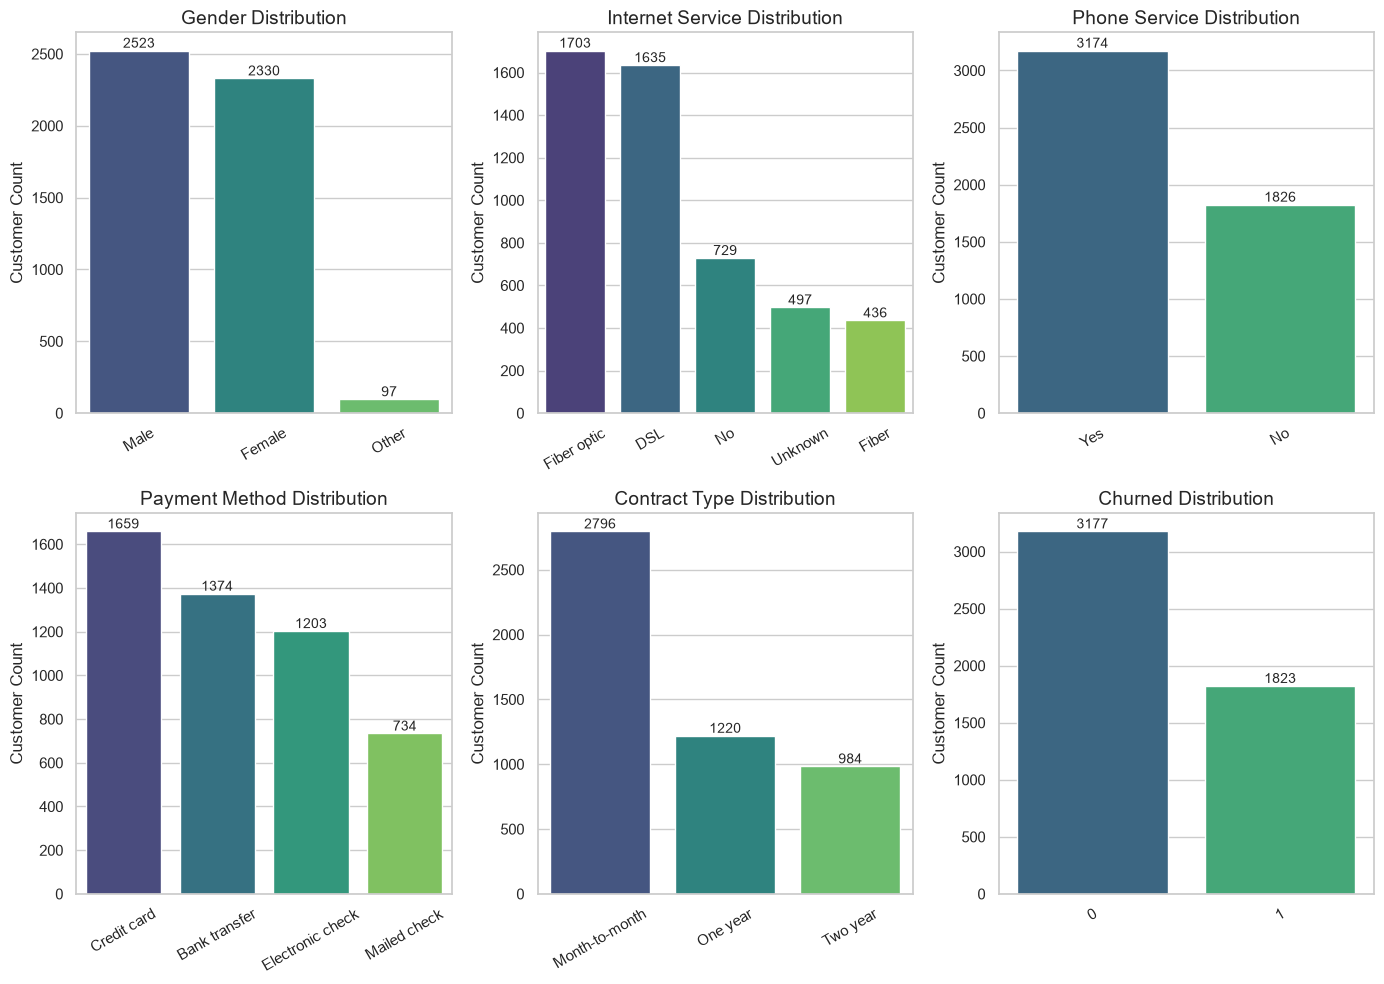

In [13]:
cols = ['gender', 'internet_service', 'phone_service', 'payment_method', 'contract_type', 'churned']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette="viridis",
        ax=ax
    )
    
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("Customer Count")
    ax.tick_params(axis='x', rotation=30)
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

correlation = df[numeric_cols].corr()['churned'].sort_values(ascending=False)

print(correlation)

churned                    1.000000
num_support_tickets        0.041145
age                        0.003232
num_additional_services   -0.002729
monthly_charges           -0.003863
avg_monthly_gb_used       -0.008861
avg_monthly_minutes       -0.018836
total_charges             -0.044526
tenure_months             -0.081618
satisfaction_score        -0.126248
Name: churned, dtype: float64


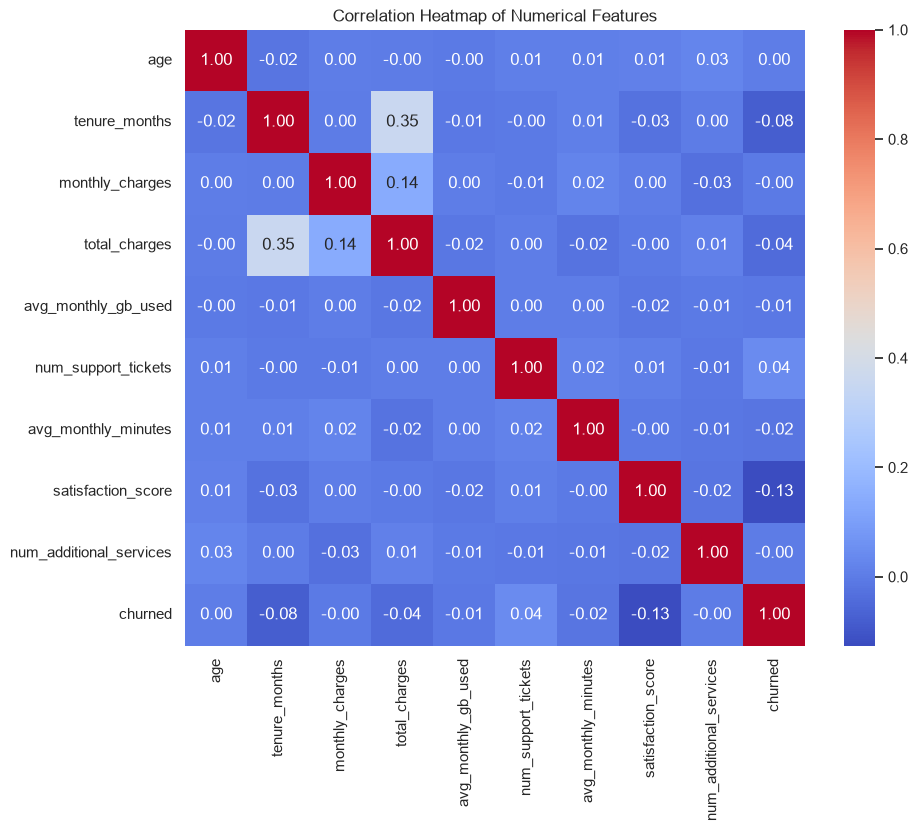

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Part 2: Encoding and Scaling Strategy

### Data Cleaning

#### Convert Date Column

In [16]:
# df["last_interaction_date"] = pd.to_datetime(
#     df["last_interaction_date"]
# )

In [17]:
# df["interaction_year"] = (
#     df["last_interaction_date"].dt.year
# )

# df["interaction_month"] = (
#     df["last_interaction_date"].dt.month
# )

# df["interaction_day"] = (
#     df["last_interaction_date"].dt.day
# )


# # Drop original date
# df.drop(
#     columns=["last_interaction_date"],
#     inplace=True
# )

#### Remove Customer Identifier

In [18]:
df.drop(
    columns=["customer_id", "last_interaction_date", "age"],
    inplace=True
)

#### Split Features and Target

In [19]:
X = df.drop(
    columns=["churned"]
)

y = df["churned"]


print(X.shape)
print(y.value_counts())

(5000, 13)
churned
0    3177
1    1823
Name: count, dtype: int64


#### Identify Feature Types

In [20]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns


categorical_features = X.select_dtypes(
    include=["object"]
).columns


print("Numerical:")
print(list(numeric_features))


print("\nCategorical:")
print(list(categorical_features))

Numerical:
['tenure_months', 'monthly_charges', 'total_charges', 'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes', 'satisfaction_score', 'num_additional_services']

Categorical:
['gender', 'contract_type', 'internet_service', 'phone_service', 'payment_method']


### Train Test Split

In [21]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Churn rate in training: {y_train.mean():.2%}")

Training samples: 3500
Test samples: 1500
Churn rate in training: 36.46%


In [22]:
X_train.head()

,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services
2335,Female,9.079101,Month-to-month,104.54,1041.49,DSL,Yes,10.80,3.0,578.90,6.3,Electronic check,1
4929,Female,7.011293,Month-to-month,44.02,143.12,No,Yes,1.23,4.0,257.40,6.4,Electronic check,2
473,Female,1.923610,One year,32.36,59.80,No,Yes,1.60,3.0,296.05,4.4,Electronic check,2
4147,Male,6.624752,Month-to-month,87.26,387.08,DSL,No,12.06,1.0,324.30,5.5,Credit card,5
2116,Male,14.226943,Month-to-month,101.48,1329.01,DSL,Yes,10.95,3.0,402.00,8.0,Bank transfer,2


#### Handle class imbalance

In [23]:
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Build pipeline
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)   
    ]
)


X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_processed, y_train)
print(np.unique(y_train_res, return_counts=True))

(array([0, 1]), array([2112, 2112]))


### Track Experiments

In [24]:
models = [
    (
        "Logistic Regression", 
        {"C": 1, "solver": 'liblinear'},
        LogisticRegression(), 
        (X_train_processed, y_train),
        (X_test_processed, y_test)
    ),
    (
        "Random Forest", 
        {"n_estimators": 30, "max_depth": 3},
        RandomForestClassifier(), 
        (X_train_processed, y_train),
        (X_test_processed, y_test)
    ),
    (
        "XGBClassifier",
        {"use_label_encoder": False, "eval_metric": 'logloss'},
        XGBClassifier(), 
        (X_train_processed, y_train),
        (X_test_processed, y_test)
    ),
    (
        "XGBClassifier With SMOTE",
        {"use_label_encoder": False, "eval_metric": 'logloss'},
        XGBClassifier(), 
        (X_train_res, y_train_res),
        (X_test_processed, y_test)
    )
]

In [25]:
reports = []

for model_name, params, model, train_set, test_set in models:
    X_train_curr, y_train_curr = train_set
    X_test_curr, y_test_curr = test_set
    
    model.set_params(**params)
    model.fit(X_train_curr, y_train_curr)
    y_pred = model.predict(X_test_curr)
    report = classification_report(y_test_curr, y_pred, output_dict=True)
    reports.append(report)

reports

[{'0': {'precision': 0.704932735426009,
   'recall': 0.8247639034627492,
   'f1-score': 0.7601547388781431,
   'support': 953.0},
  '1': {'precision': 0.5662337662337662,
   'recall': 0.39853747714808047,
   'f1-score': 0.4678111587982833,
   'support': 547.0},
  'accuracy': 0.6693333333333333,
  'macro avg': {'precision': 0.6355832508298875,
   'recall': 0.6116506903054149,
   'f1-score': 0.6139829488382131,
   'support': 1500.0},
  'weighted avg': {'precision': 0.6543538446605711,
   'recall': 0.6693333333333333,
   'f1-score': 0.6535467800090209,
   'support': 1500.0}},
 {'0': {'precision': 0.6492693110647182,
   'recall': 0.9790136411332634,
   'f1-score': 0.7807531380753138,
   'support': 953.0},
  '1': {'precision': 0.6825396825396826,
   'recall': 0.07861060329067641,
   'f1-score': 0.14098360655737704,
   'support': 547.0},
  'accuracy': 0.6506666666666666,
  'macro avg': {'precision': 0.6659044968022003,
   'recall': 0.5288121222119699,
   'f1-score': 0.4608683723163454,
   's

In [26]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

In [28]:
# Initialize MLflow
mlflow.set_experiment("Customer Churn Prediction Test1")
mlflow.set_tracking_uri("http://localhost:5000")

run_ids = {}

for i, element in enumerate(models):
    model_name = element[0]
    params = element[1]
    model = element[2]
    report = reports[i]
    
    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_params(params)
        mlflow.log_metrics({
            'accuracy': report['accuracy'],
            'recall_class_1': report['1']['recall'],
            'recall_class_0': report['0']['recall'],
            'f1_score_macro': report['macro avg']['f1-score']
        })
        
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")

        run_ids[model_name] = run.info.run_id

print(run_ids)

2026/07/22 23:03:11 INFO mlflow.tracking.fluent: Experiment with name 'Customer Churn Prediction Test1' does not exist. Creating a new experiment.
2026/07/22 23:03:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Logistic Regression at: http://localhost:5000/#/experiments/1/runs/5dbc7fe96f6d48bc9d2f01cb6c8e3e75
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/22 23:03:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/5c0be920770f40c0880072e58c553d68
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/22 23:04:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://localhost:5000/#/experiments/1/runs/ff0c758bbde14073a0f167bfb4e3f2d8
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/07/22 23:04:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier With SMOTE at: http://localhost:5000/#/experiments/1/runs/7e793e3e2f1d4b798a9b90151cc9c8fb
🧪 View experiment at: http://localhost:5000/#/experiments/1
{'Logistic Regression': '5dbc7fe96f6d48bc9d2f01cb6c8e3e75', 'Random Forest': '5c0be920770f40c0880072e58c553d68', 'XGBClassifier': 'ff0c758bbde14073a0f167bfb4e3f2d8', 'XGBClassifier With SMOTE': '7e793e3e2f1d4b798a9b90151cc9c8fb'}


### Register the Model

In [29]:
import time
import mlflow

TIMEOUT = 180  # 3 minutes
model_name = "XGBClassifier With SMOTE"

# Use the run id logged in this notebook execution
run_id = run_ids.get(model_name)
if run_id is None:
    raise ValueError(f"Run ID for '{model_name}' not found. Re-run the MLflow tracking cell first.")

start_time = time.time()

try:
    registration = mlflow.register_model(
        model_uri=f"runs:/{run_id}/model",
        name=model_name
    )

    elapsed = time.time() - start_time
    registered_version = int(registration.version)

    if elapsed > TIMEOUT:
        raise TimeoutError(f"{model_name} registration exceeded 3 minutes.")

    print(f"{model_name} registered as version {registered_version} in {elapsed:.2f} seconds.")

except TimeoutError as e:
    print(f"{e}")

except Exception as e:
    print(f"Registration failed: {e}")

Successfully registered model 'XGBClassifier With SMOTE'.
2026/07/22 23:04:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 7e793e3e2f1d4b798a9b90151cc9c8fb has no artifacts at artifact path 'model', registering model based on models:/m-10b49e7c642e4e5daa71747d690919eb instead
2026/07/22 23:04:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBClassifier With SMOTE, version 1
Created version '1' of model 'XGBClassifier With SMOTE'.


XGBClassifier With SMOTE registered as version 1 in 1.58 seconds.


### Load the Model

In [30]:
client = mlflow.MlflowClient()

# Prefer the version just registered in this run; otherwise fallback to latest version
if 'registered_version' in globals():
    model_version = registered_version
else:
    versions = client.search_model_versions(f"name='{model_name}'")
    if not versions:
        raise ValueError(f"No registered versions found for model '{model_name}'.")
    model_version = max(int(v.version) for v in versions)

model_uri = f"models:/{model_name}/{model_version}"
loaded_model = mlflow.xgboost.load_model(model_uri)

# Use the same transformed feature space used during training
y_pred = loaded_model.predict(X_test_processed)
y_pred[:4]

array([0, 0, 0, 1])

### Transition the Model to Production

In [31]:
client = mlflow.MlflowClient()

# Keep challenger alias on the source model version selected in this notebook run
source_model_name = model_name
source_version = str(model_version)

client.set_registered_model_alias(
    name=source_model_name,
    alias="challenger",
    version=source_version
)

print(f"Challenger alias assigned: {source_model_name} v{source_version}")

Challenger alias assigned: XGBClassifier With SMOTE v1


In [32]:
current_model_uri = f"models:/{model_name}@challenger"
production_model_name = "churn-prediction-test1-prod"

client = mlflow.MlflowClient()
copied_version = client.copy_model_version(
    src_model_uri=current_model_uri,
    dst_name=production_model_name
)

# Point production alias to the just-copied destination version
client.set_registered_model_alias(
    name=production_model_name,
    alias="production",
    version=str(copied_version.version)
)

print(
    f"Production alias assigned: {production_model_name} v{copied_version.version}"
)

Successfully registered model 'churn-prediction-test1-prod'.
Copied version '1' of model 'XGBClassifier With SMOTE' to version '1' of model 'churn-prediction-test1-prod'.


Production alias assigned: churn-prediction-test1-prod v1


In [33]:
import mlflow.pyfunc

production_model_uri = "models:/churn-prediction-test1-prod@production"
model = mlflow.pyfunc.load_model(production_model_uri)

# Predict on transformed features to match training schema
y_pred = model.predict(X_test_processed)

print(y_pred[:10])

[0 0 0 1 1 1 0 0 0 1]


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Basic metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6353
Precision: 0.5000
Recall   : 0.4442
F1 Score : 0.4705

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       953
           1       0.50      0.44      0.47       547

    accuracy                           0.64      1500
   macro avg       0.60      0.59      0.60      1500
weighted avg       0.63      0.64      0.63      1500


Confusion Matrix:
[[710 243]
 [304 243]]


In [35]:
import mlflow

with mlflow.start_run(run_name="production_model_evaluation"):

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

print("Production model metrics logged")

🏃 View run production_model_evaluation at: http://localhost:5000/#/experiments/1/runs/1233d6b859514705be61bbe2fa03b630
🧪 View experiment at: http://localhost:5000/#/experiments/1
Production model metrics logged
